In [1]:
import chipwhisperer as cw
import chipwhisperer.common.results.glitch as glitch
import numpy as np
import time

# --- USER CONFIGURATION ---
# *** IMPORTANT:BITSTREAM PATH ***
BITSTREAM_FILEPATH = r'C:\Users\sbista\ChipWhisperer\chipwhisperer\firmware\fpgas\aes\vivado\cw305_aes.runs\impl_100t\cw305_top.bit'

# Set a fixed key and plaintext for consistent testing
KEY = bytearray([0x2B, 0x7E, 0x15, 0x16, 0x28, 0xAE, 0xD2, 0xA6, 0xAB, 0xF7, 0x15, 0x88, 0x09, 0xCF, 0x4F, 0x3C])
PLAINTEXT = bytearray([0x5C, 0x69, 0x2F, 0x91, 0x03, 0xB2, 0x30, 0x29, 0x14, 0xD7, 0xE5, 0x55, 0xE4, 0xDC, 0xEE, 0x49])
EXPECTED_CIPHERTEXT = bytearray([0x06, 0xF3, 0x6A, 0x65, 0xE8, 0xA9, 0x9F, 0xF8, 0x90, 0x7B, 0x2E, 0x5E, 0x5D, 0xDD, 0x77, 0xDE])

#expected=06f36a65e8a99ff8907b2e5e5ddd77de
#outputou=06f36a65e8a99ff8907b2e5e5ddd77de
          #04f36a65e8a99fd8907b0e5e5ddd77de
#0.88targ=04f36a65e8a99ff8907b2e5e5ddd77de
#0.86targ=04f36a65e8a99ff8907b2e5e5ddd77de
#0.87targ=04f36a65e8a99dd8907b0e5e5ddd57de
#0.8799999=04f36a65e8a99ff8907b2e5e5ddd77de
#0.86targ=04d14845c8899dd890590c5c5ddd54dc
# Attack Parameters

NUM_GLITCH_ATTEMPTS = 500 # Number of times to try glitching
NUM_NORMAL_TRACES = 10000 # Number of traces without glitch for comparison

VCC_INT_TARGET = 1.0
# --- CONNECTION ---
scope = cw.scope()
target = cw.target(scope, cw.targets.CW305, bsfile=BITSTREAM_FILEPATH, force=True)
target.vccint_set(VCC_INT_TARGET)
print(f"Target VCC-INT set to: {target.vccint_get()}V")

# Setup PLL1 on CW305 (assuming 10MHz external clock is provided by CW-Lite)
target.pll.pll_outfreq_set(5E6, 1) # Set PLL1 to 50 MHz (common FPGA clock)
target.pll.pll_enable_set(True)
target.pll.pll_outenable_set(True, 1)

# --- CONFIGURE CW-LITE SCOPE FOR POWER TRACING ---
# Use the clock generated by the CW305 (EXTCLK) as the ADC clock source
scope.default_setup()
scope.clock.adc_src = "extclk_x4" # Use 4x the target clock for sampling
scope.adc.samples = 400 # Number of samples to capture per trace
scope.adc.offset = 0
scope.gain.gain = 25
scope.adc.presamples = 0
scope.adc.basic_mode = "falling_edge"
scope.trigger.triggers = 'tio4' # FPGA trigger pin TIO4 is used to arm the scope/glitch
scope.io.tio1 = "serial_tx"
scope.io.tio2 = "serial_rx"
scope.io.tio3 = "high_z" # Not used
scope.io.tio4 = "high_z" # Used for trigger, set by FPGA

# --- CONFIGURE CW-LITE GLITCH MODULE ---
scope.glitch.clk_src = "target" # Clock source for the glitch is the Target's EXTCLK
scope.glitch.trigger_src = "ext_single" # Wait for an external trigger (FPGA TIO4)
scope.glitch.output = "glitch_only" # Glitch pin pulls VCC-INT to ground (Crowbar)
scope.io.glitch_lp = True # Enable the low-power crowbar MOSFET
scope.io.glitch_hp = False

# Reset the glitch mechanism
scope.io.vglitch_reset()

(ChipWhisperer Target WARNING|File CW305.py:591) Using default Verilog defines (C:\Users\sbista\ChipWhisperer\chipwhisperer\software\chipwhisperer/hardware/firmware/cw305/cw305_aes_defines.v); if this is not what you want, provide them via the defines_files argument


Target VCC-INT set to: 1.0V
scope.gain.mode                          changed from low                       to high                     
scope.gain.gain                          changed from 0                         to 30                       
scope.gain.db                            changed from 5.5                       to 24.8359375               
scope.adc.basic_mode                     changed from low                       to rising_edge              
scope.adc.samples                        changed from 24400                     to 5000                     
scope.adc.trig_count                     changed from 1865922101                to 1879860202               
scope.clock.adc_src                      changed from clkgen_x1                 to clkgen_x4                
scope.clock.adc_freq                     changed from 96000000                  to 33260868                 
scope.clock.adc_rate                     changed from 96000000.0                to 33260868.0       

In [2]:
import time
for i in range(5):
    scope.clock.reset_adc()
    time.sleep(1)
    if scope.clock.adc_locked:
        break 
assert (scope.clock.adc_locked), "ADC failed to lock"

In [3]:
## --- 2. CAPTURE NORMAL TRACES ---
print("\n--- Collecting Normal Traces ---")
# Storage for the normal traces
normal_traces = []

# Function to run the AES encryption on the target
def run_aes(target, plaintext, key):
    target.set_key(key)
    target.simpleserial_write('p', plaintext)
    # The target.go() is handled by simpleserial_write for the CW305 target
    
    # Read the output from the target
    try:
        response = target.simpleserial_read('r', 16)
        if len(response) == 16:
            return response, True
        else:
            return None, False
    except Exception as e:
        print(f"Target read error: {e}")
        return None, False

for i in range(10):
    scope.arm()
    output, success = run_aes(target, PLAINTEXT, KEY)
    
    if scope.capture():
        print(f"Timeout occurred on trace {i}")
        continue

    trace = scope.get_last_trace()
    normal_traces.append(trace)
    
    # Verify the output is the expected ciphertext
    #if output == EXPECTED_CIPHERTEXT:
        #print(f"Trace {i}: Success, Output: {output.hex()}")
    #else:
        #print(f"Trace {i}: FAIL, Output: {output.hex() if output else 'N/A'}")

    if output != EXPECTED_CIPHERTEXT:
        print(f"Trace {i}: FAIL, Output: {output.hex() if output else 'N/A'}")
        
print(f"Baseline trace collection complete. Collected {len(normal_traces)} good traces.")


--- Collecting Normal Traces ---
Baseline trace collection complete. Collected 10 good traces.


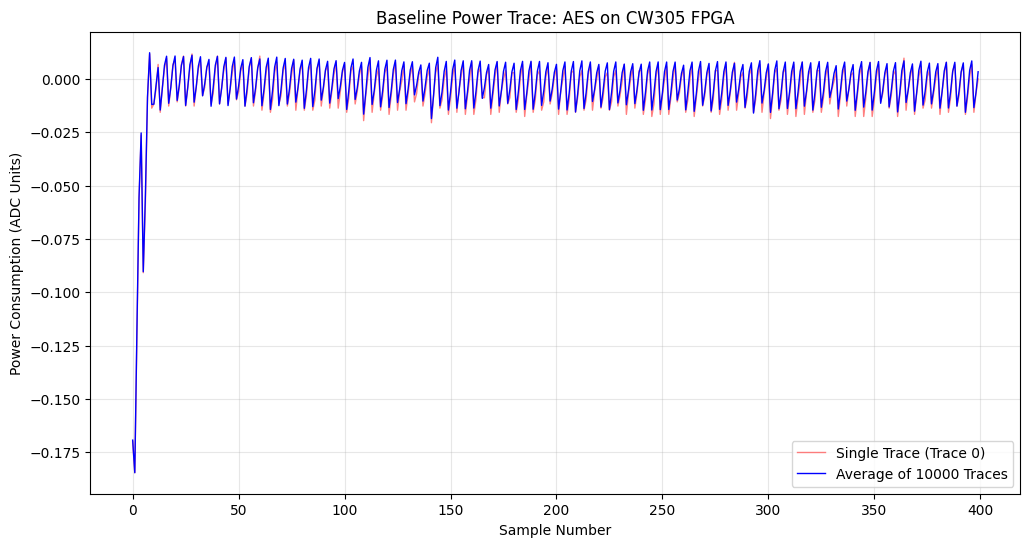

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# Ensure your normal_traces list has data
if not normal_traces:
    print("Error: No traces were collected. Run the 'Normal Trace Collection' loop first.")
else:
    # --- PLOT SETUP ---
    
    # 1. Get the first trace as a baseline
    first_trace = np.array(normal_traces[0])
    
    # 2. Get the average of all collected traces (provides a cleaner view)
    average_trace = np.average(normal_traces, axis=0)
    
    # --- PLOTTING ---
    plt.figure(figsize=(12, 6))
    
    # Plot the first collected trace
    plt.plot(first_trace, label="Single Trace (Trace 0)", color='red', alpha=0.5,linewidth=1)
    
    # Plot the average trace
    plt.plot(average_trace, label=f"Average of {len(normal_traces)} Traces", color='blue', linewidth=1)
    
    plt.title("Baseline Power Trace: AES on CW305 FPGA")
    plt.xlabel("Sample Number")
    plt.ylabel("Power Consumption (ADC Units)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

In [4]:
glitched_results = []
successful_faults = 0
successful_params = []
# --- VCC_INT SWEEP DEFINITION ---
# Start safe (1.0V) and go down to crash point (0.70V), in 10 steps
VCC_INT_TARGET = 0.9
VCC_SWEEP = np.linspace(0.9, 0.70, 10)  # VCC_SWEEP range from 1.0V to 0.70V

# --- OFFSET SWEEP DEFINITION ---
OFFSETS = np.linspace(-40.0, 40.0, 80)
FIXED_WIDTH = 4
ATTEMPTS_PER_POINT = 1

print("\n--- Starting Nested VCC/Offset Sweep ---")
print(f"Total Attempts: {len(VCC_SWEEP) * len(OFFSETS) * ATTEMPTS_PER_POINT}")


for vcc in VCC_SWEEP:
    # 1. SET THE NEW VULNERABLE VOLTAGE
    target.vccint_set(vcc)
    scope.glitch.width = FIXED_WIDTH
    
    # 2. SWEEP OFFSET AT THIS VOLTAGE LEVEL
    for offset in OFFSETS:
        scope.glitch.offset = offset
        
        # 3. ATTEMPT GLITCH MULTIPLE TIMES
        for attempt in range(ATTEMPTS_PER_POINT):
            
            i = len(glitched_results) # Tracking total attempts
            
            scope.arm()
            output, success = run_aes(target, PLAINTEXT, KEY)

            # --- CRASH & REPROGRAM LOGIC ---
            if scope.capture():
                # Handle timeout/crash
                try:
                    target.fpga_write(BITSTREAM_FILEPATH)
                except:
                    pass
                # Log the crash for plotting later
                glitched_results.append({'result': 'TIMEOUT', 'vcc': vcc, 'offset': offset})
                print(f"Attempt {i}: TIMEOUT (VCC={vcc:.2f}, o={offset:.1f}). Reprogrammed.")
                continue
            
            # --- FAULT DETECTION LOGIC ---
            output_hex = output.hex() if output else "N/A"
            expected_hex = EXPECTED_CIPHERTEXT.hex()
            
            if output_hex != expected_hex:
                result = 'FAULT'
                successful_faults += 1
            else:
                result = 'NORMAL'
                
            # Log the result
            glitched_results.append({'result': result, 'vcc': vcc, 'offset': offset, 'output': output_hex})
            
            # ---  STATEMENT TO SHOW OUTPUT ---
            if result == 'FAULT':
                print(f"Attempt {i}: **FAULT** (VCC={vcc:.2f}, o={offset:.1f}) OUTPUT: {output_hex}")
                successful_params.append({'vcc': vcc, 'offset': offset, 'output': output_hex})
            else:
                # Prints the correct output for monitoring
                print(f"Attempt {i}: Normal (VCC={vcc:.2f}, o={offset:.1f}) OUTPUT: {output_hex}")


--- Starting Nested VCC/Offset Sweep ---
Total Attempts: 800
Attempt 0: Normal (VCC=0.90, o=-40.0) OUTPUT: 06f36a65e8a99ff8907b2e5e5ddd77de
Attempt 1: Normal (VCC=0.90, o=-39.0) OUTPUT: 06f36a65e8a99ff8907b2e5e5ddd77de
Attempt 2: Normal (VCC=0.90, o=-38.0) OUTPUT: 06f36a65e8a99ff8907b2e5e5ddd77de
Attempt 3: Normal (VCC=0.90, o=-37.0) OUTPUT: 06f36a65e8a99ff8907b2e5e5ddd77de
Attempt 4: Normal (VCC=0.90, o=-35.9) OUTPUT: 06f36a65e8a99ff8907b2e5e5ddd77de
Attempt 5: Normal (VCC=0.90, o=-34.9) OUTPUT: 06f36a65e8a99ff8907b2e5e5ddd77de
Attempt 6: Normal (VCC=0.90, o=-33.9) OUTPUT: 06f36a65e8a99ff8907b2e5e5ddd77de
Attempt 7: Normal (VCC=0.90, o=-32.9) OUTPUT: 06f36a65e8a99ff8907b2e5e5ddd77de
Attempt 8: Normal (VCC=0.90, o=-31.9) OUTPUT: 06f36a65e8a99ff8907b2e5e5ddd77de
Attempt 9: Normal (VCC=0.90, o=-30.9) OUTPUT: 06f36a65e8a99ff8907b2e5e5ddd77de
Attempt 10: Normal (VCC=0.90, o=-29.9) OUTPUT: 06f36a65e8a99ff8907b2e5e5ddd77de
Attempt 11: Normal (VCC=0.90, o=-28.9) OUTPUT: 06f36a65e8a99ff8907b2

(ChipWhisperer Scope ERROR|File OpenADC.py:824) Received fewer points than expected: 195 vs 400


Attempt 271: **FAULT** (VCC=0.62, o=-8.6) OUTPUT: 00000000000000000000000000000000
Attempt 272: **FAULT** (VCC=0.62, o=-7.6) OUTPUT: 00000000000000000000000000000000
Attempt 273: **FAULT** (VCC=0.62, o=-6.6) OUTPUT: 00000000000000000000000000000000
Attempt 274: **FAULT** (VCC=0.62, o=-5.6) OUTPUT: 00000000000000000000000000000000
Attempt 275: **FAULT** (VCC=0.62, o=-4.6) OUTPUT: 00000000000000000000000000000000
Attempt 276: **FAULT** (VCC=0.62, o=-3.5) OUTPUT: 00000000000000000000000000000000
Attempt 277: **FAULT** (VCC=0.62, o=-2.5) OUTPUT: 00000000000000000000000000000000
Attempt 278: **FAULT** (VCC=0.62, o=-1.5) OUTPUT: 00000000000000000000000000000000
Attempt 279: **FAULT** (VCC=0.62, o=-0.5) OUTPUT: 00000000000000000000000000000000


(ChipWhisperer Scope ERROR|File OpenADC.py:824) Received fewer points than expected: 396 vs 400


Attempt 280: TIMEOUT (VCC=0.62, o=0.5). Reprogrammed.
Attempt 281: **FAULT** (VCC=0.62, o=1.5) OUTPUT: 00000000000000000000000000000000
Attempt 282: **FAULT** (VCC=0.62, o=2.5) OUTPUT: 00000000000000000000000000000000
Attempt 283: **FAULT** (VCC=0.62, o=3.5) OUTPUT: 00000000000000000000000000000000
Attempt 284: TIMEOUT (VCC=0.62, o=4.6). Reprogrammed.
Attempt 285: **FAULT** (VCC=0.62, o=5.6) OUTPUT: 00000000000000000000000000000000
Attempt 286: **FAULT** (VCC=0.62, o=6.6) OUTPUT: 00000000000000000000000000000000
Attempt 287: **FAULT** (VCC=0.62, o=7.6) OUTPUT: 00000000000000000000000000000000
Attempt 288: **FAULT** (VCC=0.62, o=8.6) OUTPUT: 00000000000000000000000000000000


...

(ChipWhisperer Scope ERROR|File OpenADC.py:824) Received fewer points than expected: 399 vs 400
(ChipWhisperer Scope ERROR|File OpenADC.py:824) Received fewer points than expected: 396 vs 400


Attempt 304: **FAULT** (VCC=0.62, o=24.8) OUTPUT: 00000000000000000000000000000000
Attempt 305: TIMEOUT (VCC=0.62, o=25.8). Reprogrammed.
Attempt 306: **FAULT** (VCC=0.62, o=26.8) OUTPUT: 00000000000000000000000000000000
Attempt 307: **FAULT** (VCC=0.62, o=27.8) OUTPUT: 00000000000000000000000000000000
Attempt 308: **FAULT** (VCC=0.62, o=28.9) OUTPUT: 00000000000000000000000000000000
Attempt 309: TIMEOUT (VCC=0.62, o=29.9). Reprogrammed.
Attempt 310: **FAULT** (VCC=0.62, o=30.9) OUTPUT: 00000000000000000000000000000000
Attempt 311: **FAULT** (VCC=0.62, o=31.9) OUTPUT: 00000000000000000000000000000000


(ChipWhisperer Scope ERROR|File OpenADC.py:824) Received fewer points than expected: 399 vs 400
(ChipWhisperer Scope ERROR|File OpenADC.py:824) Received fewer points than expected: 396 vs 400


Attempt 312: TIMEOUT (VCC=0.62, o=32.9). Reprogrammed.
Attempt 313: **FAULT** (VCC=0.62, o=33.9) OUTPUT: 00000000000000000000000000000000
Attempt 314: **FAULT** (VCC=0.62, o=34.9) OUTPUT: 00000000000000000000000000000000
Attempt 315: **FAULT** (VCC=0.62, o=35.9) OUTPUT: 00000000000000000000000000000000
Attempt 316: TIMEOUT (VCC=0.62, o=37.0). Reprogrammed.
Attempt 317: **FAULT** (VCC=0.62, o=38.0) OUTPUT: 00000000000000000000000000000000
Attempt 318: **FAULT** (VCC=0.62, o=39.0) OUTPUT: 00000000000000000000000000000000
Attempt 319: **FAULT** (VCC=0.62, o=40.0) OUTPUT: 00000000000000000000000000000000


ValueError: VCC-Int out of range 0.6V-1.1V

In [6]:
import numpy as np

# --- FINAL TARGETED GLITCH PARAMETERS ---

# Setting the pulse width back to the successful level (4.0%)
FIXED_WIDTH = 4.0 

# Sweeping VCC-INT into the vulnerable zone in fine steps (e.g., 0.01V steps)
VCC_SWEEP_RANGE = np.linspace(0.88, 0.87, 4) 

# Sweep Offset still covers the vulnerable region
SWEEP_OFFSETS = np.linspace(-10.0, 10.0, 40) # 40 steps for faster iteration

ATTEMPTS_PER_POINT = 2

# --- INITIALIZE LISTS ---
glitched_results = []
successful_faults = 0
total_attempts_run = 0

print("\n--- Starting Glitch Sweep (Lower VCC, Wider Pulse) ---")
print(f"Glitch Width: {FIXED_WIDTH}%. VCC Range: {VCC_SWEEP_RANGE[0]:.2f}V to {VCC_SWEEP_RANGE[-1]:.2f}V")

scope.glitch.width = FIXED_WIDTH
scope.glitch.repeat = 1

# Outer loop sweeps VCC_INT
for vcc in VCC_SWEEP_RANGE:
    target.vccint_set(vcc)
    
    # Inner loop sweeps Offset
    for offset in SWEEP_OFFSETS:
        scope.glitch.offset = offset
        
        for attempt in range(ATTEMPTS_PER_POINT):
            
            i = total_attempts_run
            total_attempts_run += 1
            
            scope.arm()
            output, success = run_aes(target, PLAINTEXT, KEY)

            # --- CRASH & REPROGRAM LOGIC ---
            if scope.capture():
                # Reprogram FPGA after crash
                try:
                    target.fpga_write(BITSTREAM_FILEPATH)
                except:
                    pass
                glitched_results.append({'result': 'TIMEOUT', 'vcc': vcc, 'offset': offset})
                # We expect TIMEOUTs here, but we need to log them.
                continue
            
            # --- FAULT DETECTION LOGIC ---
            output_hex = output.hex() if output else "N/A"
            expected_hex = EXPECTED_CIPHERTEXT.hex()
            
            if output_hex != expected_hex:
                result = 'FAULT'
                successful_faults += 1
                glitched_results.append({'result': result, 'vcc': vcc, 'offset': offset, 'output': output_hex})
                print(f"Attempt {i}: **FAULT** (VCC={vcc:.2f}, o={offset:.2f}) OUTPUT: {output_hex}")
                break
                
            else:
                result = 'NORMAL'

            glitched_results.append({'result': result, 'vcc': vcc, 'offset': offset, 'output': output_hex})
            
            # --- OUTPUT MONITORING ---
            if result == 'FAULT':
                # Highlight the successful faults
                print(f"Attempt {i}: **FAULT** (VCC={vcc:.2f}, o={offset:.2f}) OUTPUT: {output_hex}")
            elif result == 'NORMAL' and (i % 20) == 0:
                # Print only occasional normal results
                print(f"Attempt {i}: Normal (VCC={vcc:.2f}, o={offset:.2f}) OUTPUT: {output_hex}")


--- Starting Glitch Sweep (Lower VCC, Wider Pulse) ---
Glitch Width: 4.0%. VCC Range: 0.88V to 0.87V
Attempt 0: Normal (VCC=0.88, o=-10.00) OUTPUT: 06f36a65e8a99ff8907b2e5e5ddd77de
Attempt 20: Normal (VCC=0.88, o=-4.87) OUTPUT: 06f36a65e8a99ff8907b2e5e5ddd77de
Attempt 40: Normal (VCC=0.88, o=0.26) OUTPUT: 06f36a65e8a99ff8907b2e5e5ddd77de
Attempt 60: Normal (VCC=0.88, o=5.38) OUTPUT: 06f36a65e8a99ff8907b2e5e5ddd77de
Attempt 80: **FAULT** (VCC=0.88, o=-10.00) OUTPUT: 04f36a65e8a99fd8907b2e5e5ddd77de
Attempt 81: **FAULT** (VCC=0.88, o=-9.49) OUTPUT: 04f36a65e8a99ff8907b2e5e5ddd77de
Attempt 82: **FAULT** (VCC=0.88, o=-8.97) OUTPUT: 04f36a65e8a99ff8907b2e5e5ddd77de
Attempt 83: **FAULT** (VCC=0.88, o=-8.46) OUTPUT: 04f36a65e8a99ff8907b2e5e5ddd77de
Attempt 84: **FAULT** (VCC=0.88, o=-7.95) OUTPUT: 04f36a65e8a99ff8907b2e5e5ddd77de
Attempt 85: **FAULT** (VCC=0.88, o=-7.44) OUTPUT: 04f36a65e8a99ff8907b2e5e5ddd77de
Attempt 86: **FAULT** (VCC=0.88, o=-6.92) OUTPUT: 04f36a65e8a99ff8907b2e5e5ddd77d

In [5]:
# --- FINALIZED SWEET SPOT PARAMETERS ---
VCC_FINAL = 0.87      # Stable fault voltage
OFFSET_FINAL = -10.00 # Offset that consistently yields the fault
WIDTH_FINAL = 4.0     # Finalized width

# --- INITIALIZE FOR SINGLE ATTEMPT ---
glitched_trace_for_plot = None
attempt_result = None

target.vccint_set(VCC_FINAL)
scope.glitch.width = WIDTH_FINAL
scope.glitch.offset = OFFSET_FINAL
scope.glitch.repeat = 1

print(f"\n--- COLLECTING SINGLE FAULT TRACE at VCC={VCC_FINAL}V, Offset={OFFSET_FINAL} ---")

# Run loop until a successful fault trace is collected (max 10 attempts for stability)
for i in range(10000): 
    scope.arm()
    output, success = run_aes(target, PLAINTEXT, KEY)

    if scope.capture():
        # Handle crash (reprogram if needed)
        try:
            target.fpga_write(BITSTREAM_FILEPATH)
            print(f"Attempt {i}: TIMEOUT. Reprogrammed.")
        except:
            pass
        continue

    output_hex = output.hex()
    expected_hex = EXPECTED_CIPHERTEXT.hex()
    
    if output_hex != expected_hex and success:
        # A true fault occurred, and communication was successful
        glitched_trace_for_plot = scope.get_last_trace()
        attempt_result = output_hex
        print(f"SUCCESS: Fault Trace Collected. Output: {attempt_result}")
    else:
        # Normal run, not crash. Continue attempting.
        print(f"Attempt {i}: Normal result. Re-attempting fault...")
        
# Set VCC-INT back to a safe level immediately
target.vccint_set(1.0)


--- COLLECTING SINGLE FAULT TRACE at VCC=0.87V, Offset=-10.0 ---
SUCCESS: Fault Trace Collected. Output: 04f36a65e8a99ff8907b2e5e5ddd77de
SUCCESS: Fault Trace Collected. Output: 04f36a65e8a99ff8907b2e5e5ddd77de
SUCCESS: Fault Trace Collected. Output: 04f36a65e8a99ff8907b2e5e5ddd77de
SUCCESS: Fault Trace Collected. Output: 04f36a65e8a99ff8907b2e5e5ddd77de
SUCCESS: Fault Trace Collected. Output: 04f36a65e8a99ff8907b2e5e5ddd77de
SUCCESS: Fault Trace Collected. Output: 04f36a65e8a99ff8907b2e5e5ddd77de
SUCCESS: Fault Trace Collected. Output: 04f36a65e8a99ff8907b2e5e5ddd77de
SUCCESS: Fault Trace Collected. Output: 04f36a65e8a99ff8907b2e5e5ddd77de
SUCCESS: Fault Trace Collected. Output: 04f36a65e8a99ff8907b2e5e5ddd77de
SUCCESS: Fault Trace Collected. Output: 04f36a65e8a99ff8907b2e5e5ddd77de
SUCCESS: Fault Trace Collected. Output: 04f36a65e8a99ff8907b2e5e5ddd77de
SUCCESS: Fault Trace Collected. Output: 04f36a65e8a99ff8907b2e5e5ddd77de
SUCCESS: Fault Trace Collected. Output: 04f36a65e8a99ff890

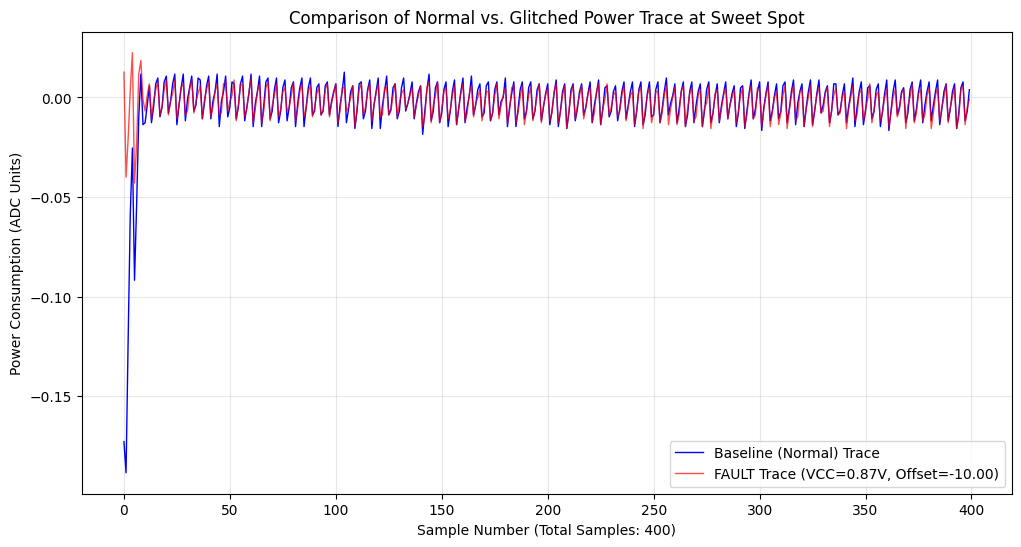

In [6]:
import matplotlib.pyplot as plt
import numpy as np

if glitched_trace_for_plot is None:
    print("\nError: Failed to capture a valid FAULT trace after 10 attempts. Check VCC_FINAL/Offset settings.")
else:
    # --- PREPARE PLOT DATA ---
    baseline_trace = np.array(normal_traces[0])
    glitched_trace = np.array(glitched_trace_for_plot)
    
    # Ensure traces have the same length
    min_len = min(len(glitched_trace), len(baseline_trace))
    glitched_trace = glitched_trace[:min_len]
    baseline_trace = baseline_trace[:min_len]

    # --- PLOT THE COMPARISON ---
    plt.figure(figsize=(12, 6))
    
    plt.plot(baseline_trace, label="Baseline (Normal) Trace", color='blue', linewidth=1)
    plt.plot(glitched_trace, 
             label=f"FAULT Trace (VCC={VCC_FINAL:.2f}V, Offset={OFFSET_FINAL:.2f})", 
             color='red', linewidth=1.0, alpha=0.7)
    
    plt.title("Comparison of Normal vs. Glitched Power Trace at Sweet Spot")
    plt.xlabel(f"Sample Number (Total Samples: {min_len})")
    plt.ylabel("Power Consumption (ADC Units)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()